Notebook for generating plots after benching french STT models

In [8]:
import os
import json
import pandas as pd
import numpy as np

from asr_benchmark.visualization.plots import prepare_data, plot_violin_df, plot_wer_df, plot_bar_df
from asr_benchmark.utils.visualize import load_data

pd.set_option("future.no_silent_downcasting", True)

In [9]:
INPUT_FOLDER = "local_bench"
OUTPUT_FOLDER = "local_plots"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
df = pd.DataFrame(load_data(INPUT_FOLDER))

100%|██████████| 10/10 [00:00<00:00, 11.50it/s]


In [10]:
df["dataset"] = df["dataset"].replace({
    "YouTubeFr_split6": "YouTube",
    "TEDX_fr": "TEDx",
    "MLS_Facebook_french": "MLS",
    "Voxpopuli": "VoxPopuli"
})
print(df["dataset"].unique())
datasets = ['CommonVoice', 'MLS', 'SUMM-RE', 'VoxPopuli', 'TEDx', 'YouTube']
all_models = df["model"].unique()
print(all_models)
models = all_models
models = [
        'whisper-large-v3-turbo', 
        'nvidia/canary-180m-flash',
        'nvidia/stt-fr-fastconformer-hybrid-large-pc', 
        'bofenghuang/stt-fr-fastconformer-hybrid-large', 
        'linagora/linto-stt-fr-fastconformer',
        'linagora/linto-stt-fr-fastconformer-pc']
df = df[
    (df['model'].isin(models))
    & ((df["decoder"] == "rnnt") | (df["decoder"].isnull()) | (df['model']=="linagora/linto-stt-fr-fastconformer-pc"))
        ]


['CommonVoice' 'MLS' 'SUMM-RE' 'TEDx' 'VoxPopuli' 'YouTube']
['whisper-large-v3-turbo' 'whisper-large-v3'
 'bofenghuang/stt-fr-fastconformer-hybrid-large'
 'linagora/linto-stt-fr-fastconformer'
 'linagora/linto-stt-fr-fastconformer-pc' 'nvidia/canary-180m-flash'
 'nvidia/canary-1b-v2' 'nvidia/canary-1b'
 'nvidia/stt-fr-fastconformer-hybrid-large-pc']


In [11]:
from asr_benchmark.visualization.table import plot_wer_table, prepare_model_name, reorder_wer_pivot

df['model'] = df.apply(lambda row: row['model']+ "\n" + row['decoder'].upper() if pd.notna(row['decoder']) else row['model'], axis=1)
wer_pivot = df.pivot(index='model', columns='dataset', values='wer')

/mnt/c/Users/berta/Documents/Linagora/asr_benchmark/asr_benchmark/visualization/table.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fontweight = 'bold' if wer_means.index[i] == min_indices[j] else 'normal'


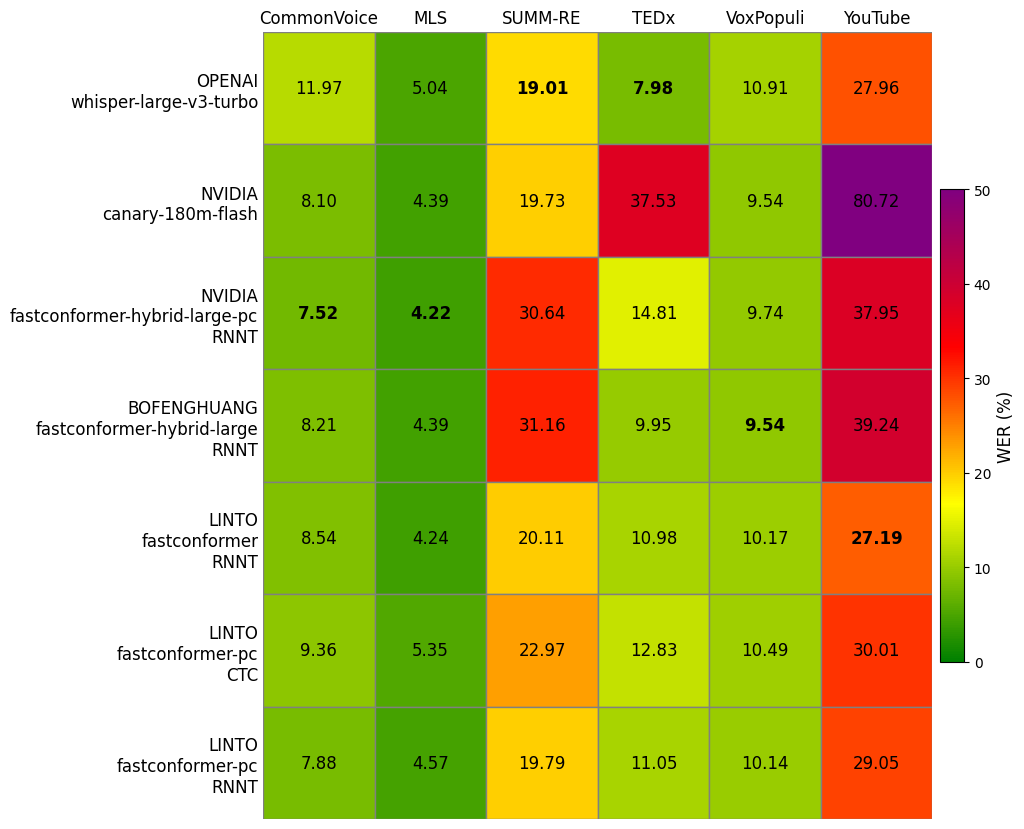

In [12]:
wer_pivot.index = [prepare_model_name(name) for name in wer_pivot.index]
wer_pivot = reorder_wer_pivot(wer_pivot)
plot_wer_table(wer_pivot, output_filename=os.path.join(OUTPUT_FOLDER, "wer_table.png"))

In [13]:
df = pd.DataFrame(load_data(INPUT_FOLDER, casepunc=True))

df["dataset"] = df["dataset"].replace({
    "YouTubeFr_split6": "YouTube",
    "TEDX_fr": "TEDx",
    "MLS_Facebook_french": "MLS",
    "Voxpopuli": "VoxPopuli"
})
print(df["dataset"].unique())
datasets = ['CommonVoice', 'MLS', 'SUMM-RE', 'VoxPopuli', 'TEDx', 'YouTube']
all_models = df["model"].unique()
print(all_models)
models = all_models
models = [
        'whisper-large-v3-turbo', 
        'nvidia/canary-180m-flash',
        'nvidia/stt-fr-fastconformer-hybrid-large-pc', 
        'bofenghuang/stt-fr-fastconformer-hybrid-large', 
        'linagora/linto-stt-fr-fastconformer',
        'linagora/linto-stt-fr-fastconformer-pc']
df = df[
    (df['model'].isin(models))
    & ((df["decoder"] == "rnnt") | (df["decoder"].isnull()) | (df['model']=="linto-stt-fr-fastconformer-pc"))
]

100%|██████████| 10/10 [00:00<00:00, 14.85it/s]

['CommonVoice' 'TEDx' 'VoxPopuli' 'YouTube']
['whisper-large-v3-turbo' 'whisper-large-v3'
 'bofenghuang/stt-fr-fastconformer-hybrid-large'
 'linagora/linto-stt-fr-fastconformer'
 'linagora/linto-stt-fr-fastconformer-pc' 'nvidia/canary-180m-flash'
 'nvidia/canary-1b-v2' 'nvidia/canary-1b'
 'nvidia/stt-fr-fastconformer-hybrid-large-pc']


/mnt/c/Users/berta/Documents/Linagora/asr_benchmark/asr_benchmark/visualization/table.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fontweight = 'bold' if wer_means.index[i] == min_indices[j] else 'normal'


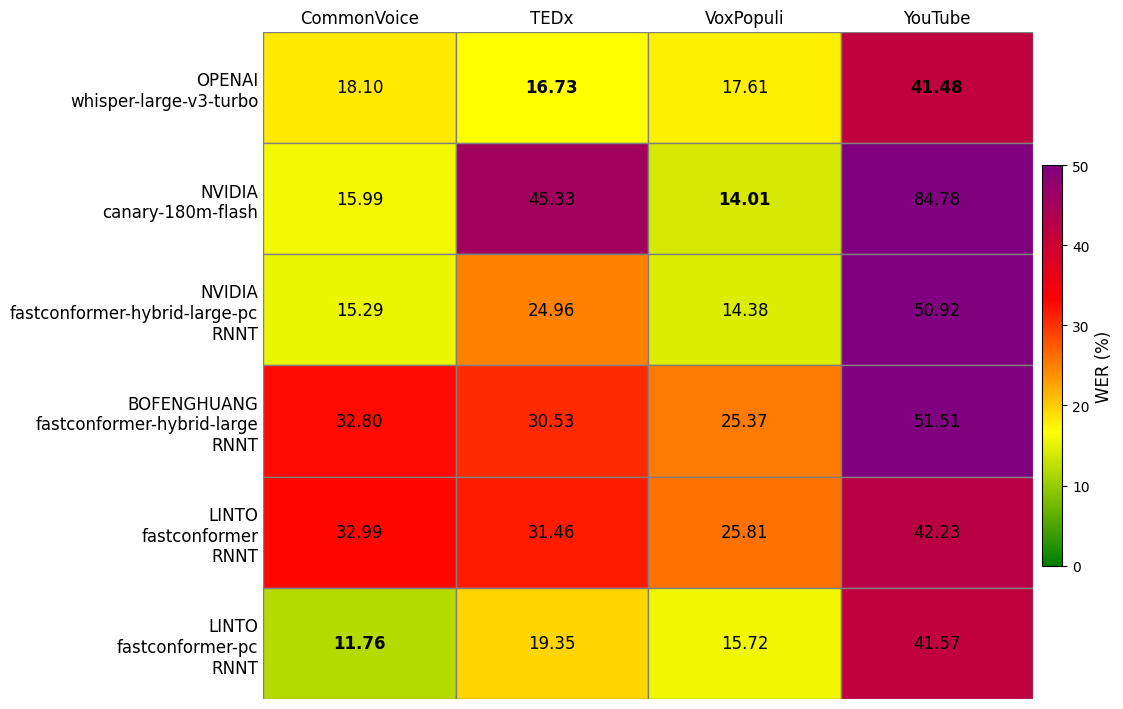

In [14]:
df['model'] = df.apply(lambda row: row['model']+ "\n" + row['decoder'].upper() if pd.notna(row['decoder']) else row['model'], axis=1)
wer_pivot = df.pivot(index='model', columns='dataset', values='wer')
wer_pivot.index = [prepare_model_name(name) for name in wer_pivot.index]
wer_pivot = reorder_wer_pivot(wer_pivot)
plot_wer_table(wer_pivot, output_filename=os.path.join(OUTPUT_FOLDER, "wer_table_casepunc.png"))